### 라이브러리 임포트

In [3]:
# --------------------------------------------------
# [1] 라이브러리 임포트 및 시각화 설정 (통합)
# --------------------------------------------------
import duckdb
import polars as pl
import pandas as pd
import os
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# 🚨 반드시 Seaborn 임포트 이후에 폰트 설정 실행
if platform.system() == 'Darwin':  # Mac 환경
    # Mac 최신 버전에서는 'Apple SD Gothic Neo'가 렌더링에 더 안정적입니다.
    plt.rc('font', family='Apple SD Gothic Neo')
elif platform.system() == 'Windows':  # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Google Colab 등) 환경
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [4]:
# --------------------------------------------------
# [2] 파일 경로 설정 및 데이터 로드
# --------------------------------------------------
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_final_mapped.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

# --------------------------------------------------
# [3] 데이터 정상 로드 확인
# --------------------------------------------------
query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
print("📌 [데이터 미리보기]")
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_final_mapped.parquet
파일 존재 여부: True

📌 [데이터 미리보기]


measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,measure_timestamp,sensor_id_matched,lat,lon,address,district
str,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,str,f64,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs],str,f64,f64,str,str
"""2020.4.4 10:00""","""V02Q1940078""",null,13.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,28128.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 16:00""","""V02Q1940078""",null,15.0,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,9479.0,null,null,1.0,null,null,null,null,0.07,0.02,null,0.11,0.05,null,1.12,1.05,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 16:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 22:00""","""V02Q1940078""",null,9.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,30.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.1,0.05,null,1.14,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 22:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 4:00""","""V02Q1940078""",null,6.3,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,26.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.11,0.04,null,1.15,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 04:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 10:00""","""V02Q1940078""",null,9.0,null,null,1.0,null,0.0,0.0,null,0.0,0.0,null,null,30247.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""


# [0] 기초 통계량 및 결측치 파악

In [5]:
query_summarize = """
    SUMMARIZE v_sdot;
"""
df_summary = duckdb.sql(query_summarize).df()

print("📌 [전체 데이터 기본 통계량 및 결측치 요약]")
# 요약 결과 중 컬럼명, 데이터타입, 최소/최대/평균, 널(Null) 비율 위주로 출력
display(df_summary[['column_name', 'column_type', 'min', 'max', 'approx_unique', 'avg', 'null_percentage']])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [전체 데이터 기본 통계량 및 결측치 요약]


,column_name,column_type,min,max,approx_unique,avg,null_percentage
0,measure_time,VARCHAR,2020-09-01 0:00,2026-07-19_23:07:00,30672,None,0.00
1,sensor_id,VARCHAR,OC3CL200008,V02Q2300007,1259,None,0.00
2,temp_max,VARCHAR,-0.1,9.9,1527,None,18.19
3,temp_avg,DOUBLE,-40.0,965.8,1084,15.060596291642922,6.14
4,temp_min,VARCHAR,-0.1,9.9,1030,None,18.20
...,...,...,...,...,...,...,...
129,sensor_id_matched,VARCHAR,OC3CL200010,V02Q2300007,1245,None,0.00
130,lat,DOUBLE,37.06194967,37.690991222,1209,37.54882728447833,0.01
131,lon,DOUBLE,126.799983213,127.17936066,1031,126.98702906853296,0.01
132,address,VARCHAR,경기도 과천시 서울대공원,서울특별시 중랑구 중랑천로24길 19,925,None,0.01


# 위치 미상 센서의 측정 기간 파악

In [6]:
# 위치미상 센서 20건의 생존 기간 확인 쿼리

import pandas as pd

# Pandas 출력 시 행이 잘리지 않도록 최대 출력 줄 수 설정
pd.set_option('display.max_rows', 30)


query_unknown_lifespan = """
    SELECT 
        sensor_id_matched,
        MIN(measure_timestamp) AS 최초_수집일,
        MAX(measure_timestamp) AS 최종_수집일,
        DATE_DIFF('day', MIN(measure_timestamp), MAX(measure_timestamp)) AS 데이터_수집_기간_일수,
        DATE_DIFF('day', MAX(measure_timestamp), CURRENT_DATE) AS 수집중단_경과일
    FROM v_sdot
    WHERE district = '위치미상'
    GROUP BY sensor_id_matched
    ORDER BY 최종_수집일 ASC
"""

df_unknown_lifespan = duckdb.sql(query_unknown_lifespan).pl()

print("📌 [위치미상 센서 20건 측정 기간 확인]")
display(df_unknown_lifespan.to_pandas())

📌 [위치미상 센서 20건 측정 기간 확인]


,sensor_id_matched,최초_수집일,최종_수집일,데이터_수집_기간_일수,수집중단_경과일
0,V02Q1940922,2020-04-02 17:00:00,2020-04-02 17:00:00,0,2314
1,V02Q1940963,2020-04-02 15:00:00,2020-04-03 11:00:00,1,2313
2,V02Q1940933,2020-04-03 16:00:00,2020-04-03 16:00:00,0,2313
3,V02Q1940982,2020-04-01 01:00:00,2020-04-03 17:00:00,2,2313
4,V02Q1940921,2020-04-16 13:00:00,2020-04-16 13:00:00,0,2300
5,OT2CL200002,2020-05-06 10:35:00,2020-05-06 10:35:00,0,2280
6,V02Q1950001,2020-05-13 14:45:00,2020-05-14 08:46:00,1,2272
7,V02Q1940936,2020-06-10 14:19:00,2020-06-10 14:19:00,0,2245
8,OT3CL180000,2020-06-22 16:34:00,2020-06-23 10:35:00,1,2232
9,OC3DL220002,2023-10-24 01:07:00,2023-10-27 12:07:00,3,1011


# 자치구별 소멸 센서

### 30일 이상 중단

In [ ]:
query_sensor_lifespan = """
    SELECT 
        sensor_id_matched,
        MIN(measure_timestamp) AS first_seen,
        MAX(measure_timestamp) AS last_seen,
        DATE_DIFF('day', MAX(measure_timestamp), CAST('2026-07-19' AS TIMESTAMP)) AS days_since_last_seen,
        address
    FROM v_sdot
    GROUP BY sensor_id_matched, address
    HAVING days_since_last_seen > 30  -- 마지막 측정일이 전체 데이터 끝점보다 30일 이상 차이나는 경우
    ORDER BY days_since_last_seen DESC
"""

df_dead_sensors = duckdb.sql(query_sensor_lifespan).pl()

# ✅ 소멸 센서 총개수 출력 추가
print(f"🚨 총 소멸(기록 중단) 센서 개수: {len(df_dead_sensors)}개\n")

print("📌 [일찍 기록이 멈춘 센서 리스트 TOP 10]")
display(df_dead_sensors.head(10))

🚨 총 소멸(기록 중단) 센서 개수: 159개

📌 [일찍 기록이 멈춘 센서 리스트 TOP 10]


sensor_id_matched,first_seen,last_seen,days_since_last_seen,address
str,datetime[μs],datetime[μs],i64,str
"""V02Q1940922""",2020-04-02 17:00:00,2020-04-02 17:00:00,2299,null
"""V02Q1940933""",2020-04-03 16:00:00,2020-04-03 16:00:00,2298,null
"""V02Q1940963""",2020-04-02 15:00:00,2020-04-03 11:00:00,2298,null
"""V02Q1940982""",2020-04-01 01:00:00,2020-04-03 17:00:00,2298,null
"""V02Q1940921""",2020-04-16 13:00:00,2020-04-16 13:00:00,2285,null
"""OT2CL200002""",2020-05-06 10:35:00,2020-05-06 10:35:00,2265,null
"""V02Q1950001""",2020-05-13 14:45:00,2020-05-14 08:46:00,2257,null
"""V02Q1940936""",2020-06-10 14:19:00,2020-06-10 14:19:00,2230,null
"""OT3CL180000""",2020-06-22 16:34:00,2020-06-23 10:35:00,2217,null


### 1년 이상 중단

📌 [자치구별 '진짜 소멸(1년 이상 중단)' 센서 집계 결과]


,자치구,소멸_센서_수,평균_수집중단_일수,가장_오래된_중단일,가장_최근_중단일
0,위치미상,10,2144.0,2020-04-02 17:00:00,2023-10-27 12:07:00
1,광진구,2,1468.0,2021-11-14 23:00:00,2023-03-10 12:07:00
2,은평구,2,697.0,2024-08-21 03:07:00,2024-08-21 03:07:00
3,강동구,1,682.0,2024-09-05 12:07:00,2024-09-05 12:07:00
4,동작구,1,418.0,2025-05-27 10:07:00,2025-05-27 10:07:00
5,서대문구,1,494.0,2025-03-12 15:07:00,2025-03-12 15:07:00
6,영등포구,1,471.0,2025-04-04 02:07:00,2025-04-04 02:07:00
7,중구,1,366.0,2025-07-18 02:07:00,2025-07-18 02:07:00


/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_55847/1427993486.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


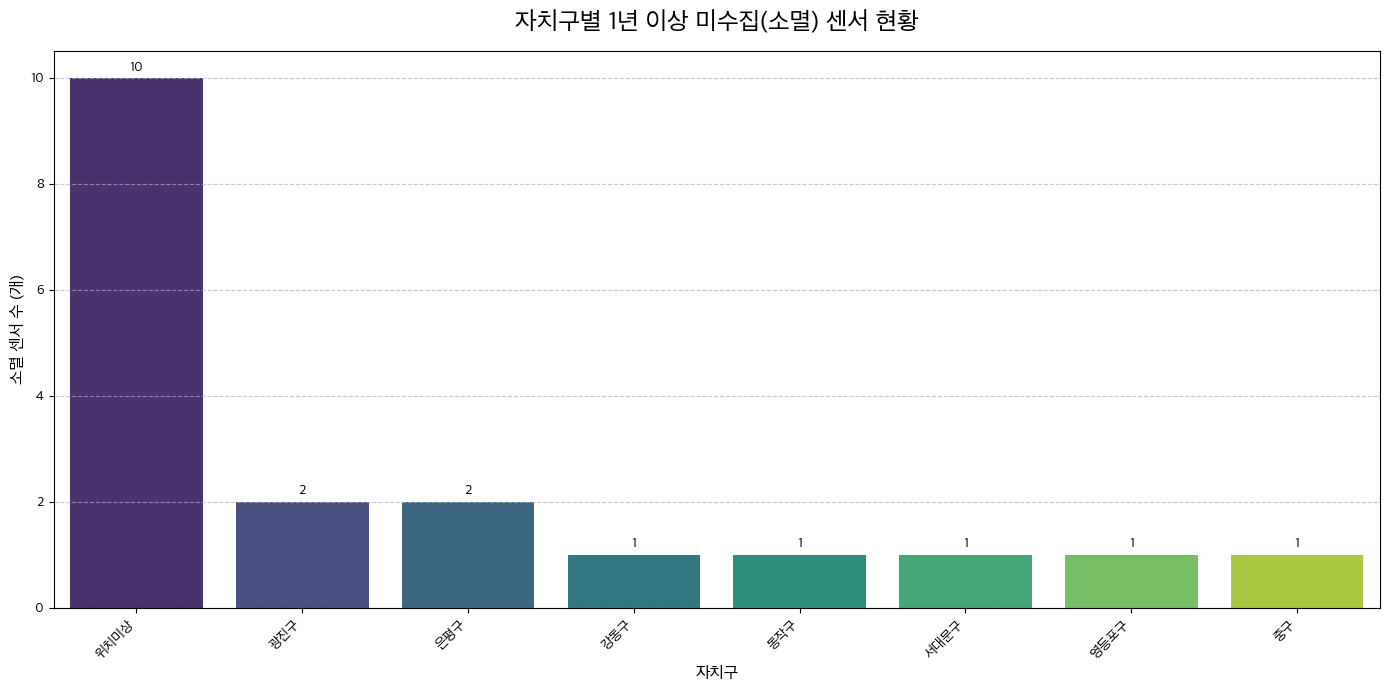

In [8]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pandas 출력 옵션 설정
pd.set_option('display.max_rows', 50)

# 2. SQL 쿼리 작성 (1년 이상 중단 기준)
query_true_dead_sensors = """
    WITH global_max AS (
        -- 전체 데이터의 가장 최신 시점 파악
        SELECT MAX(measure_timestamp) AS max_time 
        FROM v_sdot
    ),
    sensor_lifespan AS (
        -- 센서별 최종 수집일 및 수집 중단 일수 계산
        SELECT 
            sensor_id_matched,
            district,
            MAX(measure_timestamp) AS last_measure,
            DATE_DIFF('day', MAX(measure_timestamp), (SELECT max_time FROM global_max)) AS dead_days
        FROM v_sdot
        GROUP BY sensor_id_matched, district
    ),
    dead_sensors_filtered AS (
        -- 🚨 진짜 소멸 기준: 마지막 측정일로부터 1년(365일) 이상 경과한 센서
        SELECT * 
        FROM sensor_lifespan 
        WHERE dead_days >= 365
    )
    -- 자치구별 진짜 소멸 센서 현황 집계
    SELECT 
        district AS 자치구,
        COUNT(sensor_id_matched) AS 소멸_센서_수,
        ROUND(AVG(dead_days), 0) AS 평균_수집중단_일수,
        MIN(last_measure) AS 가장_오래된_중단일,
        MAX(last_measure) AS 가장_최근_중단일
    FROM dead_sensors_filtered
    GROUP BY district
    ORDER BY 소멸_센서_수 DESC, 자치구 ASC
"""

# 3. 쿼리 실행 및 데이터프레임 변환
df_true_dead = duckdb.sql(query_true_dead_sensors).df()

print("📌 [자치구별 '진짜 소멸(1년 이상 중단)' 센서 집계 결과]")
display(df_true_dead)


# 시각화 캔버스 설정
plt.figure(figsize=(14, 7))

# 막대그래프 생성
ax = sns.barplot(
    data=df_true_dead, 
    x='자치구', 
    y='소멸_센서_수', 
    palette='viridis'
)

# 막대 위에 정확한 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0인 경우는 표시 생략
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 3), 
                    textcoords='offset points')

# 차트 꾸미기
plt.title("자치구별 1년 이상 미수집(소멸) 센서 현황", fontsize=18, pad=15)
plt.xlabel("자치구", fontsize=12)
plt.ylabel("소멸 센서 수 (개)", fontsize=12)
plt.xticks(rotation=45, ha='right')  # 자치구 이름이 겹치지 않게 45도 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 출력
plt.show()

### 6개월 이상 중단

In [9]:
# --------------------------------------------------
# [6] 조기 소멸 센서의 자치구/모델별 결함 원인 파악
# --------------------------------------------------
# 6개월(180일) 이상 수집이 중단된 센서를 '소멸 센서'로 정의하여 특징 분석
query_dead_analysis = """
    WITH latest_time AS (
        SELECT MAX(measure_timestamp) AS max_time FROM v_sdot
    ),
    sensor_stats AS (
        SELECT 
            sensor_id_matched,
            MAX(district) AS 자치구,
            -- 만약 v_sdot 뷰에 장비 모델명(예: model_nm) 컬럼이 없다면 주석 처리하세요.
            -- MAX(model_nm) AS 장비모델, 
            DATE_DIFF('day', MAX(measure_timestamp), (SELECT max_time FROM latest_time)) AS gap_days
        FROM v_sdot
        GROUP BY sensor_id_matched
    )
    SELECT 
        자치구,
        COUNT(*) AS 소멸_센서_수
    FROM sensor_stats
    WHERE gap_days >= 180
    GROUP BY 자치구
    ORDER BY 소멸_센서_수 DESC
"""
df_dead_dist = duckdb.sql(query_dead_analysis).pl()
print("📌 [자치구별 장기 통신 두절(180일 이상) 센서 분포]")
display(df_dead_dist)

📌 [자치구별 장기 통신 두절(180일 이상) 센서 분포]


자치구,소멸_센서_수
str,i64
"""위치미상""",20
"""강북구""",4
"""종로구""",3
"""마포구""",3
"""은평구""",3
…,…
"""구로구""",1
"""중랑구""",1
"""강동구""",1


# 센서 생존 기간 타임라인 시각화 (Gantt Chart)

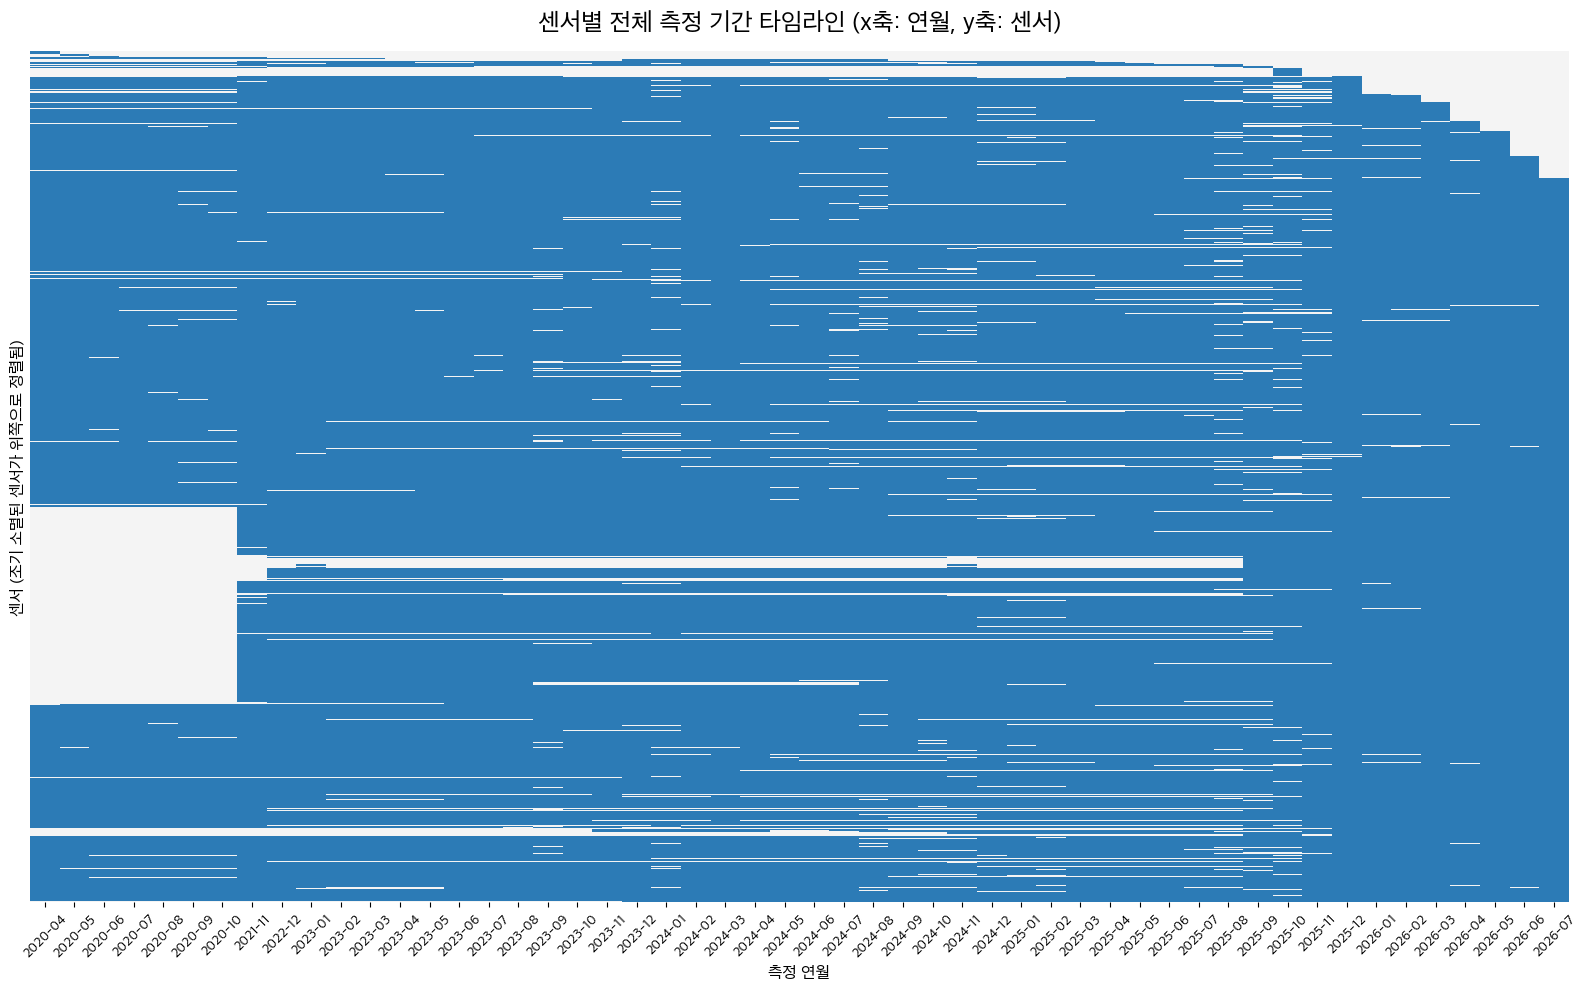

In [10]:
# --------------------------------------------------
# [5] 센서 생존 기간 및 결측 패턴 타임라인 시각화
# --------------------------------------------------
# 1. 월별 데이터 수집 건수 집계 (데이터가 너무 많으므로 월 단위로 1차 압축)
query_timeline = """
    SELECT 
        sensor_id_matched,
        DATE_TRUNC('month', measure_timestamp) AS measure_month,
        COUNT(*) AS record_count
    FROM v_sdot
    GROUP BY sensor_id_matched, measure_month
"""
df_timeline = duckdb.sql(query_timeline).df()

# 월별 데이터를 문자열(YYYY-MM)로 변환
df_timeline['measure_month'] = df_timeline['measure_month'].dt.strftime('%Y-%m')

# 2. 피벗 테이블 생성 (Index: 센서, Columns: 연월, Values: 수집 건수)
pivot_timeline = df_timeline.pivot(index='sensor_id_matched', columns='measure_month', values='record_count')

# 데이터 유무만 보기 위해 값이 있으면 1, 결측(NaN)이면 0으로 이진화
pivot_binary = pivot_timeline.notna().astype(int)

# 🚨 시각화를 위해 '가장 먼저 수집이 끊긴 센서' 순으로 정렬
# (마지막으로 1이 등장하는 컬럼 인덱스를 찾아 정렬)
last_active_month = pivot_binary.apply(lambda row: row.to_numpy().nonzero()[0][-1] if row.sum() > 0 else 0, axis=1)
pivot_binary_sorted = pivot_binary.iloc[last_active_month.argsort()]

# 3. 타임라인 히트맵 시각화
plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_binary_sorted, 
    cmap=['#f4f4f4', '#2c7bb6'],  # 0(결측)은 옅은 회색, 1(수집)은 파란색
    cbar=False, 
    yticklabels=False  # 센서 개수가 너무 많아 y축 라벨은 생략
)

plt.title("센서별 전체 측정 기간 타임라인 (x축: 연월, y축: 센서)", fontsize=18, pad=15)
plt.xlabel("측정 연월", fontsize=12)
plt.ylabel("센서 (조기 소멸된 센서가 위쪽으로 정렬됨)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()